# **Appointments and OADR (Old age dependency ratio)**

#### HYPOTHESIS : OADR could be a proxy for population complexity and therefore number of GP appointments per annum

- calculate OADR for each ICB in 2021-22 (FY) and compare to number of appointments (per head of population), is there a correlation?
- OADR = number of pension in a population / working age in a population
- fit a model (linear sklearn)
- Retired/Old age >= 65
- 20 > Working age < 65

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from schemas import DataCatalog
import constants as const
import seaborn as sns
import scipy.stats as stats

# Module Constants

In [100]:
GP_APPOINTMENTS_NAME = 'NHS GP Appointments by Region'
GP_PATIENT_LIST = 'Patients Registered at a GP practice, October 2023'
APPOINTMENTS_START = '2022-09-01'
APPOINTMENTS_EEND = '2023-08-30'

# Load Data Sources

## Data catalog

In [101]:
#Loading the Catalog
catalog =  DataCatalog.load_from_yaml("data_catalog.yaml")

## NHS GP Appointments by Region (1)

In [102]:
#Loading the dataset
gp_appts_catalog_entry = [i for i in catalog.single_data_sources if i.name ==GP_APPOINTMENTS_NAME].pop()
#Combining the dats/csv's for all ICB's
dfs = []
gp_appts_catalog_entry.load()
for ccg_name in gp_appts_catalog_entry.zip_file.namelist():
    # iterate over all files in the zip file
    gp_appts_catalog_entry.csv_file = ccg_name
    dfs.append(gp_appts_catalog_entry.load())

gp_appts_df = pd.concat(dfs, axis=0)
gp_appts_df.head()


,SUB_ICB_LOCATION_CODE,SUB_ICB_LOCATION_ONS_CODE,SUB_ICB_LOCATION_NAME,ICB_ONS_CODE,ICB_NAME,REGION_ONS_CODE,REGION_NAME,APPOINTMENT_MONTH,APPT_STATUS,HCP_TYPE,APPT_MODE,TIME_BETWEEN_BOOK_AND_APPT,COUNT_OF_APPOINTMENTS
0,02T,E38000025,NHS West Yorkshire ICB - 02T,E54000054,NHS West Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,MAR2021,Attended,GP,Face-to-Face,1 Day,1999
1,02T,E38000025,NHS West Yorkshire ICB - 02T,E54000054,NHS West Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,MAR2021,Attended,GP,Face-to-Face,15 to 21 Days,329
2,02T,E38000025,NHS West Yorkshire ICB - 02T,E54000054,NHS West Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,MAR2021,Attended,GP,Face-to-Face,2 to 7 Days,4194
3,02T,E38000025,NHS West Yorkshire ICB - 02T,E54000054,NHS West Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,MAR2021,Attended,GP,Face-to-Face,22 to 28 Days,212
4,02T,E38000025,NHS West Yorkshire ICB - 02T,E54000054,NHS West Yorkshire Integrated Care Board,E40000012,North East and Yorkshire,MAR2021,Attended,GP,Face-to-Face,8 to 14 Days,1101


## GP List - October 2023 (2)

In [103]:
#Loading the dataset
gp_list_sizes_catalog_entry = [i for i in catalog.single_data_sources if i.name ==GP_PATIENT_LIST].pop()
gp_list_df = gp_list_sizes_catalog_entry.load()
gp_list_df.head()

/workspaces/PrimaryCareDemandAndCapacity/schemas.py:148: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(csv_file, **read_csv_kwargs)


,PUBLICATION,EXTRACT_DATE,ORG_TYPE,ORG_CODE,ONS_CODE,POSTCODE,SEX,AGE_GROUP_5,NUMBER_OF_PATIENTS
0,GP_PRAC_PAT_LIST,01Oct2023,Comm Region,Y56,E40000003,NaN,ALL,ALL,10927943
1,GP_PRAC_PAT_LIST,01Oct2023,Comm Region,Y56,E40000003,NaN,FEMALE,0_4,258852
2,GP_PRAC_PAT_LIST,01Oct2023,Comm Region,Y56,E40000003,NaN,FEMALE,10_14,300771
3,GP_PRAC_PAT_LIST,01Oct2023,Comm Region,Y56,E40000003,NaN,FEMALE,15_19,287618
4,GP_PRAC_PAT_LIST,01Oct2023,Comm Region,Y56,E40000003,NaN,FEMALE,20_24,385681


# Data Cleaning

## Appointments (1)

### Filter months & sum by sub-ICB

In [104]:
gp_appts_2023_df = gp_appts_df.copy()
# convert to datetime
gp_appts_2023_df['APPOINTMENT_MONTH'] = pd.to_datetime(gp_appts_2023_df['APPOINTMENT_MONTH'], format='%b%Y')
# filter to september 2023
gp_appts_2023_df = gp_appts_df.loc[gp_appts_2023_df['APPOINTMENT_MONTH']>='2022-09-01'].copy()
# group by ICB and month
gp_appts_summary_df = gp_appts_2023_df.groupby(['SUB_ICB_LOCATION_ONS_CODE','SUB_ICB_LOCATION_NAME','APPOINTMENT_MONTH']).agg({'COUNT_OF_APPOINTMENTS':'sum'}).reset_index()
gp_appts_summary_df.head(20)


,SUB_ICB_LOCATION_ONS_CODE,SUB_ICB_LOCATION_NAME,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS
0,E38000006,NHS South Yorkshire ICB - 02P,APR2023,114962
1,E38000006,NHS South Yorkshire ICB - 02P,AUG2023,133143
2,E38000006,NHS South Yorkshire ICB - 02P,DEC2022,114950
3,E38000006,NHS South Yorkshire ICB - 02P,FEB2023,122989
4,E38000006,NHS South Yorkshire ICB - 02P,JAN2023,130670
5,E38000006,NHS South Yorkshire ICB - 02P,JUL2023,128186
6,E38000006,NHS South Yorkshire ICB - 02P,JUN2023,135611
7,E38000006,NHS South Yorkshire ICB - 02P,MAR2023,138932
8,E38000006,NHS South Yorkshire ICB - 02P,MAY2023,128581
9,E38000006,NHS South Yorkshire ICB - 02P,NOV2022,136021


In [105]:
monthly_appts_df = (monthly_appts_df
                    .assign(
                        ndays = lambda df: df['APPOINTMENT_MONTH'].map(lambda x: pd.bdate_range(start=x,end=x+pd.offsets.MonthEnd(0), 
                        holidays=const.ENGLAND_BANK_HOLIDAYS, 
                        freq='C').shape[0],),
                        appts_per_day_per_month=lambda df: df['COUNT_OF_APPOINTMENTS']/df['ndays'])
                    .drop(columns=['ndays']))

## GP List

### Cleaning
1. Only gendered data has age bands, so drop 'ALL' values from age group, this will also drop the 'ALL' values from gender.
2. Extract the lower band of the age groups (left hand of bin) as integer.
3. Calculate number of patients within:
    - Working age. 20>=x<64
    - Retirement age. x>65
    - Child age. 20<x


In [106]:
def replace_age_bands(age_band_string:str)->int:
    """
    This function takes in a string of the format '0_4' and returns the corresponding age band '0-4'
    """
    # take left hand number and add 5 to it
    if '+' in age_band_string:
        return 90
    else:
        return int(age_band_string.split('_')[0])

# remove 'all' as this does not contain age bands
gp_list_filtered_df = gp_list_df.loc[(gp_list_df['AGE_GROUP_5']!='ALL') & (gp_list_df['ORG_TYPE']=='SUB_ICB_LOCATION')].copy()
#Replacing AGE_BANDS values to match the ONS_projection data
gp_list_filtered_df['LB_AGE_GROUP'] = gp_list_filtered_df['AGE_GROUP_5'].map(replace_age_bands)
# Calculate patients in each group
gp_list_filtered_df['WORKAGE'] = gp_list_filtered_df['LB_AGE_GROUP'].map(lambda x: 1 if x>=20 and x<=64 else 0) * gp_list_filtered_df['NUMBER_OF_PATIENTS']
gp_list_filtered_df['RETIREAGE'] = gp_list_filtered_df['LB_AGE_GROUP'].map(lambda x: 1 if x>=65 else 0) * gp_list_filtered_df['NUMBER_OF_PATIENTS']
gp_list_filtered_df['CHILDAGE'] = gp_list_filtered_df['LB_AGE_GROUP'].map(lambda x: 1 if x < 20 else 0) * gp_list_filtered_df['NUMBER_OF_PATIENTS']
gp_list_filtered_df.head()

,PUBLICATION,EXTRACT_DATE,ORG_TYPE,ORG_CODE,ONS_CODE,POSTCODE,SEX,AGE_GROUP_5,NUMBER_OF_PATIENTS,LB_AGE_GROUP,WORKAGE,RETIREAGE,CHILDAGE
329854,GP_PRAC_PAT_LIST,01Oct2023,SUB_ICB_LOCATION,00L,E38000130,NaN,FEMALE,0_4,6603,0,0,0,6603
329855,GP_PRAC_PAT_LIST,01Oct2023,SUB_ICB_LOCATION,00L,E38000130,NaN,FEMALE,10_14,8820,10,0,0,8820
329856,GP_PRAC_PAT_LIST,01Oct2023,SUB_ICB_LOCATION,00L,E38000130,NaN,FEMALE,15_19,8285,15,0,0,8285
329857,GP_PRAC_PAT_LIST,01Oct2023,SUB_ICB_LOCATION,00L,E38000130,NaN,FEMALE,20_24,7313,20,7313,0,0
329858,GP_PRAC_PAT_LIST,01Oct2023,SUB_ICB_LOCATION,00L,E38000130,NaN,FEMALE,25_29,8384,25,8384,0,0


### Summary statistics
1. Calculate OADR.
2. Calculate CADR.
3. Calculate.
4. Calculate total patients.

In [107]:
oadr_df = gp_list_filtered_df.groupby(['ONS_CODE'])[['WORKAGE','RETIREAGE','CHILDAGE']].sum().reset_index().copy()
oadr_df['OADR'] = oadr_df['RETIREAGE'] / oadr_df['WORKAGE']
oadr_df['CADR'] = oadr_df['CHILDAGE'] / oadr_df['WORKAGE']
oadr_df['total_list_size'] = oadr_df['WORKAGE'] + oadr_df['RETIREAGE'] + oadr_df['CHILDAGE']
oadr_df.head()

,ONS_CODE,WORKAGE,RETIREAGE,CHILDAGE,OADR,CADR,total_list_size
0,E38000006,156991,52159,59540,0.332242,0.379257,268690
1,E38000007,169123,51618,70481,0.305210,0.416744,291222
2,E38000008,71530,27229,26650,0.380665,0.372571,125409
3,E38000014,108524,26824,49045,0.247171,0.451928,184393
4,E38000015,104341,36502,37731,0.349834,0.361612,178574


# Analysis

## GP List

### OADR Distribution

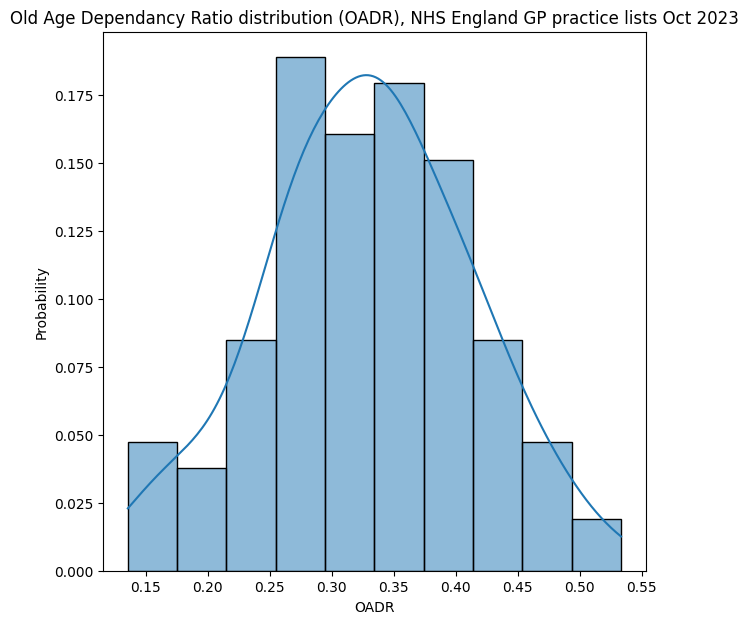

In [108]:
fig, ax = plt.subplots(1, figsize=(7, 7))
sns.histplot(data=oadr_df, x='OADR', bins=10, stat='probability', ax=ax, kde=True)
ax.set_title('Old Age Dependancy Ratio distribution (OADR), NHS England GP practice lists Oct 2023')
plt.show()

### CADR Distribution

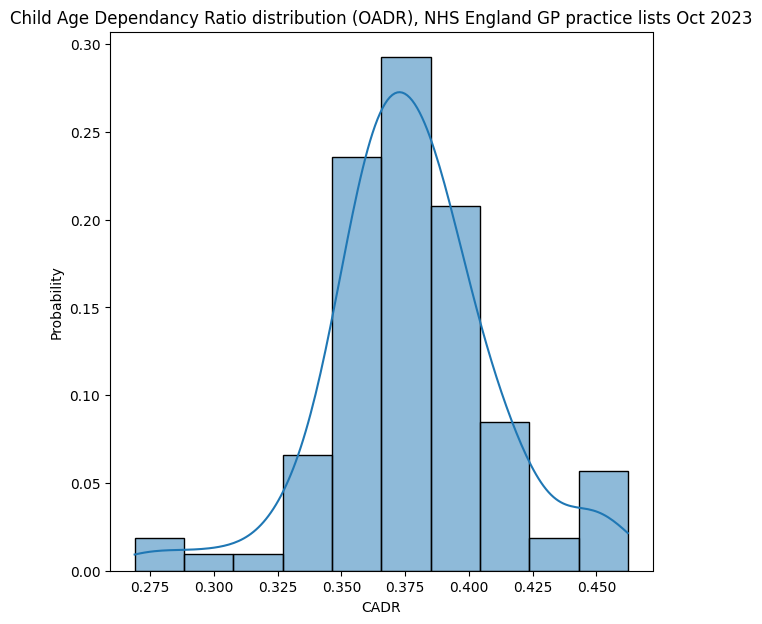

In [109]:
fig, ax = plt.subplots(1, figsize=(7, 7))
sns.histplot(data=oadr_df, x='CADR', bins=10, stat='probability', ax=ax, kde=True)
ax.set_title('Child Age Dependancy Ratio distribution (OADR), NHS England GP practice lists Oct 2023')
plt.show()

### Normality test - OADR & CADR

In [110]:
from scipy.stats import shapiro


def shapiro_test(df_:pd.DataFrame, col_name:str)->None:

    print(f"\n\nTesting {col_name} for normality")
    # extract the OADR values from the dataframe
    values = df_[col_name].values

    # perform the Shapiro-Wilk test
    stat, p = shapiro(values)

    # print the results
    print('Shapiro-Wilk test statistic:', stat)
    print('p-value:', p)

    if p > 0.05:
        print(f'{col_name} values are normally distributed,  null hypothesis (values are not normally distributed) rejected')
    else:
        print(f'{col_name} values are not normally distributed.')

for i in {'OADR','CADR'}:
    shapiro_test(oadr_df, i)



Testing OADR for normality
Shapiro-Wilk test statistic: 0.9945759773254395
p-value: 0.9534566402435303
OADR values are normally distributed,  null hypothesis (values are not normally distributed) rejected


Testing CADR for normality
Shapiro-Wilk test statistic: 0.9644840955734253
p-value: 0.0061645726673305035
CADR values are not normally distributed.


## Joined dataset

In [111]:
gp_appts_summary_df.head(20)

,SUB_ICB_LOCATION_ONS_CODE,SUB_ICB_LOCATION_NAME,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS
0,E38000006,NHS South Yorkshire ICB - 02P,APR2023,114962
1,E38000006,NHS South Yorkshire ICB - 02P,AUG2023,133143
2,E38000006,NHS South Yorkshire ICB - 02P,DEC2022,114950
3,E38000006,NHS South Yorkshire ICB - 02P,FEB2023,122989
4,E38000006,NHS South Yorkshire ICB - 02P,JAN2023,130670
5,E38000006,NHS South Yorkshire ICB - 02P,JUL2023,128186
6,E38000006,NHS South Yorkshire ICB - 02P,JUN2023,135611
7,E38000006,NHS South Yorkshire ICB - 02P,MAR2023,138932
8,E38000006,NHS South Yorkshire ICB - 02P,MAY2023,128581
9,E38000006,NHS South Yorkshire ICB - 02P,NOV2022,136021


### Joining data

### Calculating appointments per person per year

In [112]:
# inner join on ONS code
oadr_appointments_df= pd.merge(
    left=oadr_df.set_index('ONS_CODE'), 
    right=monthly_appts_df, 
    how='inner', 
    left_index=True, 
    right_on='SUB_ICB_LOCATION_ONS_CODE')
# calculate appointments per person per working day
oadr_appointments_df['appts_per_person_per_working_day'] = oadr_appointments_df['appts_per_day'] / oadr_appointments_df['total_list_size']
# calculate appointments per person per month
oadr_appointments_df = (oadr_appointments_df
                        .drop(columns=['RETIREAGE','WORKAGE','CHILDAGE'])
                        .assign(SNEE_ICB= lambda df : df['SUB_ICB_LOCATION_NAME'].str.contains('Suffolk')))

oadr_appointments_df.sort_values('appts_per_person_per_working_day', ascending=False).head(20)

,OADR,CADR,total_list_size,SUB_ICB_LOCATION_ONS_CODE,SUB_ICB_LOCATION_NAME,APPOINTMENT_MONTH,COUNT_OF_APPOINTMENTS,appts_per_day,appts_per_day_per_month,appts_per_person_per_working_day,SNEE_ICB
937,0.364320,0.360164,564765,E38000234,NHS North East and North Cumbria ICB - 84H,2022-10-01,379307,18062.238095,18062.238095,0.031982,False
853,0.533308,0.355743,185144,E38000226,NHS Lancashire and South Cumbria ICB - 02M,2022-10-01,123547,5883.190476,5883.190476,0.031776,False
380,0.363140,0.393090,173224,E38000119,NHS Humber and North Yorkshire ICB - 03H,2023-05-01,109962,5498.100000,5498.100000,0.031740,False
373,0.363140,0.393090,173224,E38000119,NHS Humber and North Yorkshire ICB - 03H,2022-10-01,114696,5461.714286,5461.714286,0.031530,False
376,0.363140,0.393090,173224,E38000119,NHS Humber and North Yorkshire ICB - 03H,2023-01-01,112280,5346.666667,5346.666667,0.030866,False
301,0.457065,0.359861,602629,E38000089,NHS Cornwall and The Isles Of Scilly ICB - 11N,2022-10-01,390189,18580.428571,18580.428571,0.030832,False
1021,0.466469,0.353005,442425,E38000241,NHS Humber and North Yorkshire ICB - 42D,2022-10-01,285837,13611.285714,13611.285714,0.030765,False
889,0.432095,0.358409,1289152,E38000230,NHS Devon ICB - 15N,2022-10-01,829097,39480.809524,39480.809524,0.030625,False
757,0.383781,0.380744,342775,E38000208,NHS Cheshire and Merseyside ICB - 12F,2022-10-01,219270,10441.428571,10441.428571,0.030461,False
381,0.363140,0.393090,173224,E38000119,NHS Humber and North Yorkshire ICB - 03H,2023-06-01,115879,5267.227273,5267.227273,0.030407,False


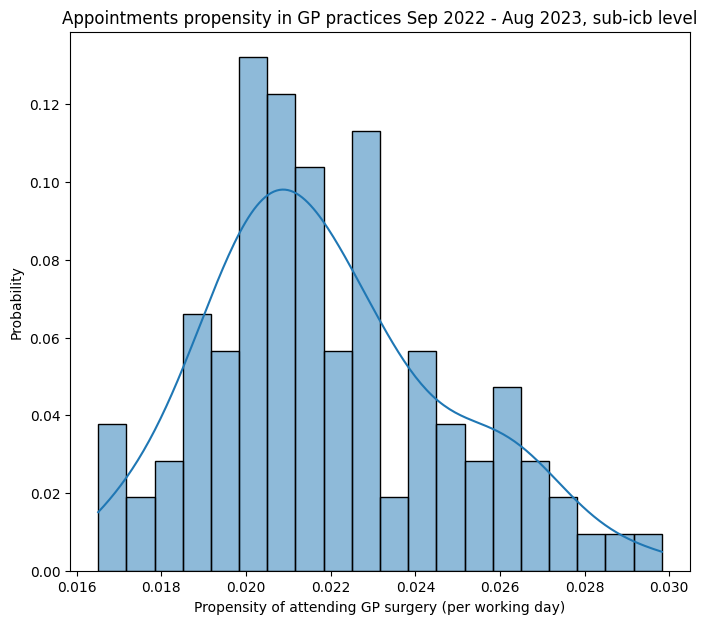

In [113]:
fig, ax = plt.subplots(1, figsize=(8, 7))
sns.histplot(data=oadr_appointments_df.groupby(['SUB_ICB_LOCATION_NAME'])[['appts_per_person_per_working_day']].mean(), x='appts_per_person_per_working_day', bins=20, stat='probability', ax=ax, kde=True)
ax.set_title('Appointments propensity in GP practices Sep 2022 - Aug 2023, sub-icb level')
ax.set_xlabel('Propensity of attending GP surgery (per working day)')
plt.show()

/tmp/ipykernel_9183/916273948.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


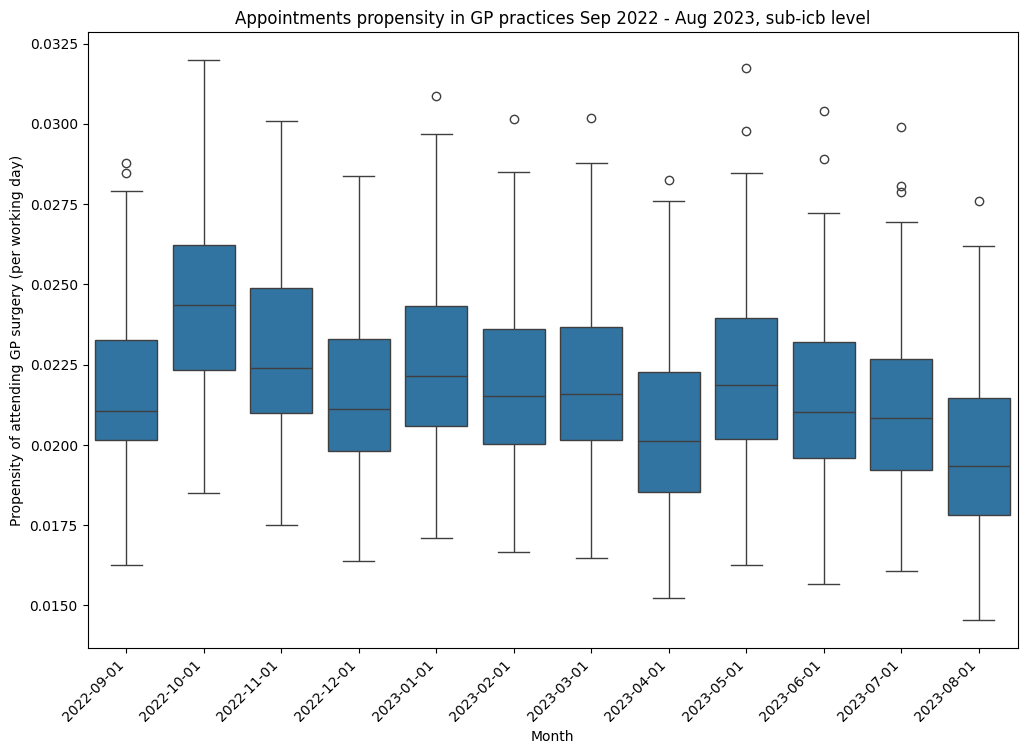

In [114]:
fig, ax = plt.subplots(1, figsize=(12, 8))
sns.boxplot(data=oadr_appointments_df, x='APPOINTMENT_MONTH', y='appts_per_person_per_working_day', ax=ax)
ax.set_title('Appointments propensity in GP practices Sep 2022 - Aug 2023, sub-icb level')
ax.set_xlabel('Month')
ax.set_ylabel('Propensity of attending GP surgery (per working day)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


### Appointments per person, normally distributed?

In [115]:
shapiro_test(oadr_appointments_df, 'appts_per_person_per_working_day')



Testing appts_per_person_per_working_day for normality
Shapiro-Wilk test statistic: 0.9805720448493958
p-value: 4.755707546516552e-12
appts_per_person_per_working_day values are not normally distributed.


### Pairplot

In [116]:
yearly_summary_appointments_df = oadr_appointments_df.groupby(['SUB_ICB_LOCATION_NAME','SNEE_ICB']).agg({'OADR':'mean','appts_per_person_per_working_day':'mean'}).reset_index()

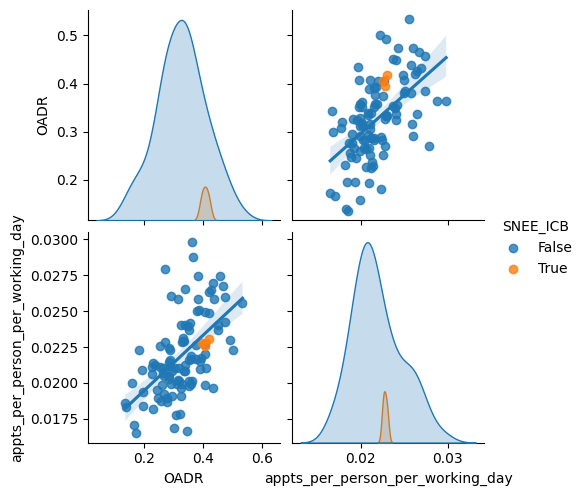

In [117]:
ax = sns.pairplot(yearly_summary_appointments_df, vars=['OADR','appts_per_person_per_working_day'], kind='reg', hue='SNEE_ICB')
plt.show()

### Significance test - is SNEE-ICB higher OADR than normal?


Does SNEE ICB have a higher OADR than the rest of the population?

In [118]:
stats.ttest_ind(yearly_summary_appointments_df['OADR'].loc[yearly_summary_appointments_df['SNEE_ICB']==True], yearly_summary_appointments_df['OADR'].loc[yearly_summary_appointments_df['SNEE_ICB']==False].values, equal_var=False)

TtestResult(statistic=7.54334215567699, pvalue=9.10096263750919e-06, df=11.428412237673243)

# Regression models

## Baseline

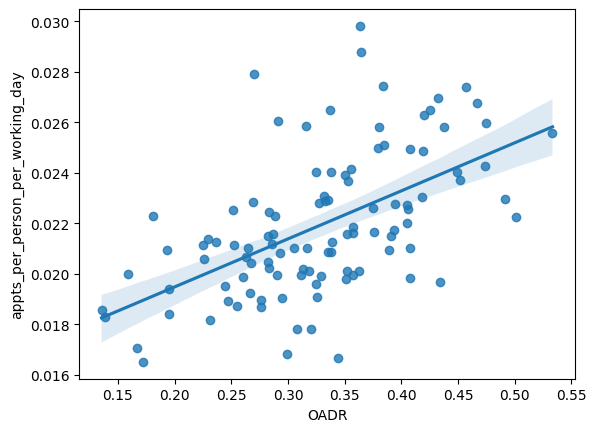

In [119]:
import seaborn as sns

sns.regplot(data=yearly_summary_appointments_df, x='OADR', y='appts_per_person_per_working_day',order=1, x_ci=0.99)
plt.show()

In [120]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', TransformedTargetRegressor(regressor=LinearRegression(), transformer=StandardScaler()))
])

# define the transformed target regressor

# fit the model
X = yearly_summary_appointments_df[['OADR']]
y = yearly_summary_appointments_df['appts_per_person_per_working_day']
pipeline.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor',
                 TransformedTargetRegressor(regressor=LinearRegression(),
                                            transformer=StandardScaler()))])

In [121]:
print(f"R^2 Score:  {pipeline.score(X, y)}")

R^2 Score:  0.31066550916062585


In [122]:
from sklearn.model_selection import cross_val_score

# define the number of folds
k = 5

# perform k-fold cross validation
scores = cross_val_score(pipeline, X, y, cv=k)

# print the mean and standard deviation of the scores
print(f'Mean score: {scores.mean()}')
print(f'Standard deviation: {scores.std()}')


Mean score: 0.16891608274783562
Standard deviation: 0.3163032714060679


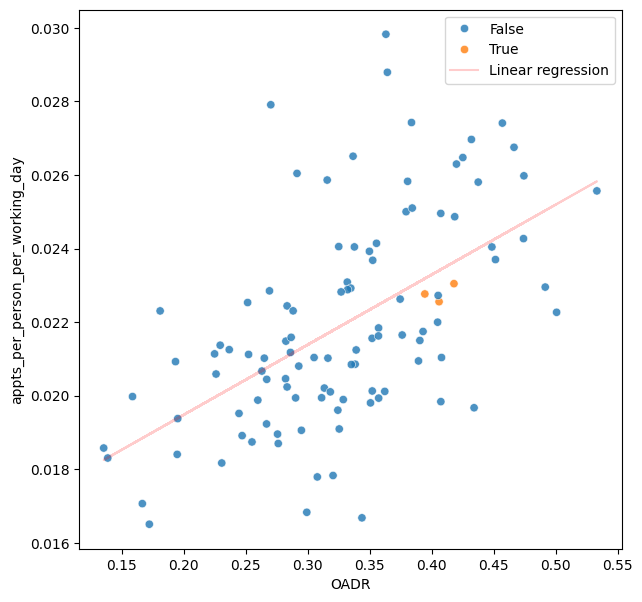

In [123]:
fig, ax = plt.subplots(1, figsize=(7, 7))
sns.scatterplot(data=yearly_summary_appointments_df, x='OADR', y='appts_per_person_per_working_day', hue='SNEE_ICB', alpha=0.8, ax=ax)
ax.plot(X, pipeline.predict(X), color='red', label='Linear regression', alpha=0.2)
ax.legend()
plt.show()


<Axes: xlabel='Residual prediction error, appointments per person per day', ylabel='Probability'>

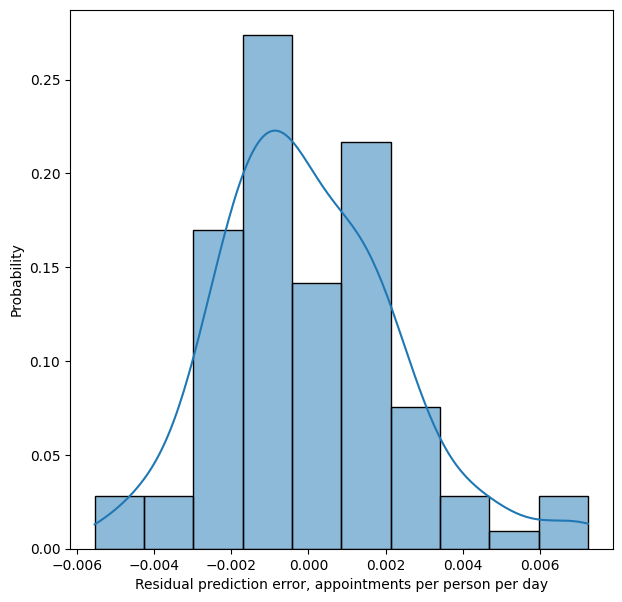

In [124]:
preds = pipeline.predict(X) # predict on the training data
residuals = y - preds # calculate the residuals
# plot residuals
residuals.name = 'Residual prediction error, appointments per person per day'
fig, ax = plt.subplots(1, figsize=(7, 7))
sns.histplot(data=residuals, bins=10, stat='probability', ax=ax, kde=True)

### Residuals normally distributed?

In [125]:
shapiro_test(pd.DataFrame(residuals), residuals.name)



Testing Residual prediction error, appointments per person per day for normality
Shapiro-Wilk test statistic: 0.9714731574058533
p-value: 0.021957041695713997
Residual prediction error, appointments per person per day values are not normally distributed.


## Adding region

In [126]:
oadr_regions_df = yearly_summary_appointments_df.merge(gp_appts_df[['REGION_NAME','SUB_ICB_LOCATION_NAME']].drop_duplicates(), on=['SUB_ICB_LOCATION_NAME'])

### EDA

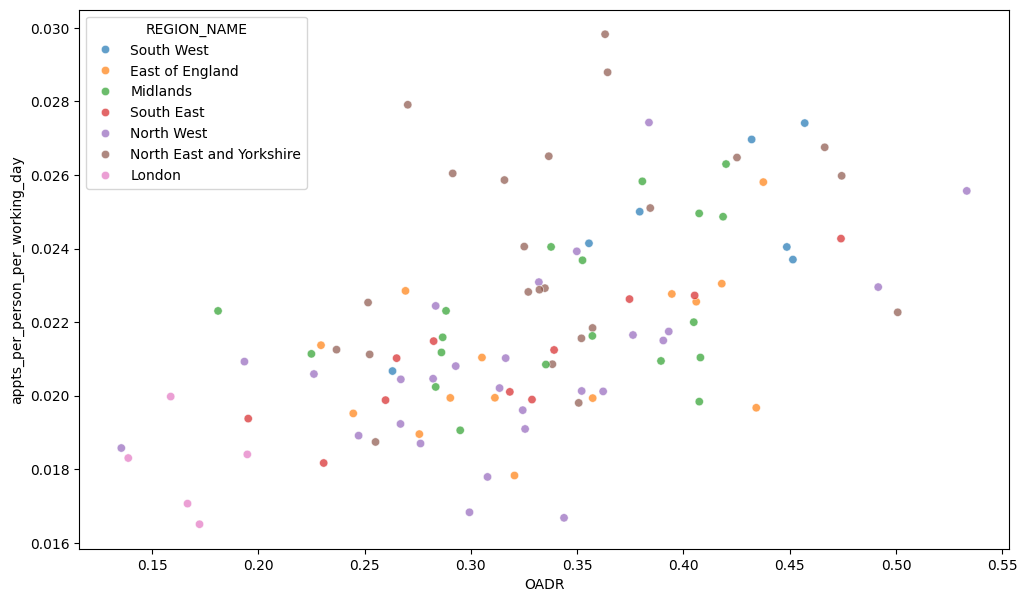

In [127]:

fig, ax = plt.subplots(1, figsize=(12, 7))
sns.scatterplot(data=oadr_regions_df, x='OADR', y='appts_per_person_per_working_day', hue='REGION_NAME', alpha=0.7)
plt.show()

In [128]:
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

# define the pipeline
regions_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), ['OADR']),
        ('cat', OneHotEncoder(), ['REGION_NAME'])
    ])),
    ('regressor', TransformedTargetRegressor(regressor=LinearRegression(), transformer=StandardScaler()))
])

# fit the model
y = oadr_regions_df['appts_per_person_per_working_day']
X_ = oadr_regions_df[['OADR','REGION_NAME']]

regions_pipeline.fit(X_, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['OADR']),
                                                 ('cat', OneHotEncoder(),
                                                  ['REGION_NAME'])])),
                ('regressor',
                 TransformedTargetRegressor(regressor=LinearRegression(),
                                            transformer=StandardScaler()))])

In [129]:
regions_pipeline.score(X_, y)

0.4832086633218171

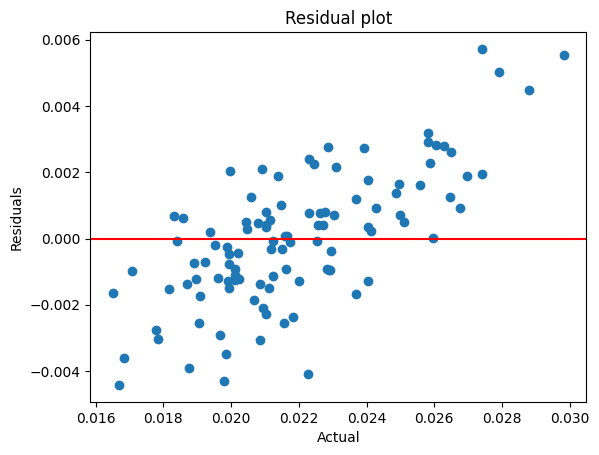

In [130]:
# calculate the residuals
residuals = y - regions_pipeline.predict(X_)

# plot the residuals
import matplotlib.pyplot as plt
plt.scatter(y, residuals)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Actual')
plt.ylabel('Residuals')
plt.title('Residual plot')
plt.show()

## Trying original bins as features

In [134]:
gp_list_grouped = gp_list_df.copy()
# remove 'all' as this does not contain age bands
gp_list_grouped = gp_list_grouped.loc[(gp_list_grouped['AGE_GROUP_5']!='ALL') & (gp_list_grouped['ORG_TYPE']=='SUB_ICB_LOCATION')].copy()
# replace _ with -
gp_list_grouped['AGE_GROUP_5'] = gp_list_grouped['AGE_GROUP_5'].str.replace("_","-")

# sum by age group
gp_list_grouped = gp_list_grouped.pivot_table(index="ONS_CODE",columns="AGE_GROUP_5", values="NUMBER_OF_PATIENTS",aggfunc="sum")

gp_list_grouped['90+'] = gp_list_grouped['95+'] + gp_list_grouped['90-94']
# drop columns
gp_list_grouped = gp_list_grouped.drop(columns=['95+','90-94'])
# divide by row total to get fractions of population
total_population_series =  gp_list_grouped.sum(axis=1)
total_population_series.name='total_population'

gp_list_grouped = gp_list_grouped.div(total_population_series, axis=0)
gp_list_grouped = pd.concat((gp_list_grouped, total_population_series), axis=1)

gp_list_grouped = gp_list_grouped.join(gp_appts_summary_df.set_index('SUB_ICB_LOCATION_ONS_CODE'))
gp_list_grouped['appts_per_person'] = gp_list_grouped['COUNT_OF_APPOINTMENTS'] / gp_list_grouped['total_population']
gp_list_grouped = gp_list_grouped.drop(columns=['total_population','COUNT_OF_APPOINTMENTS','SUB_ICB_LOCATION_NAME'])
gp_list_grouped['APPOINTMENT_MONTH'] = pd.to_datetime(gp_list_grouped['APPOINTMENT_MONTH'], format='%b%Y') 
gp_list_grouped['month_sin'] = gp_list_grouped['APPOINTMENT_MONTH'].dt.month.map(const.MONTH_CYCLICAL_ENCODING['sin'])
gp_list_grouped['month_cos'] = gp_list_grouped['APPOINTMENT_MONTH'].dt.month.map(const.MONTH_CYCLICAL_ENCODING['cos'])

AttributeError: module 'constants' has no attribute 'MONTH_CYCLICAL_ENCODING'

In [133]:
gp_list_grouped['APPOINTMENT_MONTH']

E38000006    APR2023
E38000006    AUG2023
E38000006    DEC2022
E38000006    FEB2023
E38000006    JAN2023
              ...   
E38000263    MAR2023
E38000263    MAY2023
E38000263    NOV2022
E38000263    OCT2022
E38000263    SEP2022
Name: APPOINTMENT_MONTH, Length: 1272, dtype: object

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

# define the pipeline
poly_demographic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=False)),
    ('regressor', LinearRegression())
])


# fit the model
poly_demographic_regression_df = gp_list_grouped.copy()

y = poly_demographic_regression_df.pop('appts_per_person')
X = poly_demographic_regression_df
poly_demographic_pipeline.fit(X, y)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer

# define the parameter grid for each step in the pipeline
param_grid = {
    'poly__degree': [2, 3],
    'poly__interaction_only': [True, False],
    'regressor__fit_intercept': [True, False],
    'regressor__positive': [True, False],
}

# define the grid search object
grid_search = GridSearchCV(poly_demographic_pipeline, param_grid=param_grid, cv=5, scoring=make_scorer(mean_squared_error, greater_is_better=False))

# fit the grid search object to the data
grid_search.fit(X, y)

# print the best parameters and score
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best negative mean squared error: {grid_search.best_score_}')


In [ ]:
grid_search.cv_results_['mean_test_score']

In [ ]:

poly_demographic_pipeline.set_params(**grid_search.best_params_)

poly_demographic_pipeline.fit(X, y)
predictions = poly_demographic_pipeline.predict(X)
residuals = y - predictions

# plot the residuals
fig , ax = plt.subplots(1, figsize=(7, 7))
plt.scatter(x=y, y=residuals, alpha=0.5)
ax.set_xlabel('Actual')
ax.set_ylabel('Residuals')
ax.set_title(f'Residual plot for polynomial regression on , degree: {poly_demographic_pipeline.get_params()["poly__degree"]}')
plt.show()

In [ ]:
plt.hist(y)

In [ ]:
plt.hist(predictions)

In [ ]:
import requests
from io import BytesIO
import pandas as pd

In [ ]:
response = requests.get("https://opendata.arcgis.com/api/v3/datasets/423c8069710c4d488d5ff99475688101_0/downloads/data?format=csv&spatialRefId=4326&where=1%3D1")
response.raise_for_status()

In [ ]:
content = BytesIO(response.content)
df = pd.read_csv(content)